<a href="https://colab.research.google.com/github/GigiQR99/CV-exercises/blob/main/my_Huggingface_models_M5_rquinta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HUGGING FACE MODELS**

###Student: Raquel Quintanilla
Follow instructions at: https://drlee.io/stop-paying-for-ai-apis-how-to-access-thousands-of-free-models-with-huggingface-in-30-minutes-aa9f11f17524

**The Micro-Why:**  Every model uses the same **`pipeline()`** function with just two changes: the task type and the model name. This consistency is HuggingFace’s genius.

Once you understand this pattern, you can deploy any of the 500,000+ models with minimal code changes. You’re not learning 10 different APIs. You’re learning one interface that unlocks everything

##**Step 1:** Set Up Google Colab With Your HuggingFace Token

In [ ]:
!pip install transformers torch sentencepiece accelerate

In [ ]:
from google.colab import userdata
from huggingface_hub import login
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

##**Step 2:** Load and Test 10 Different Models
Now comes the exciting part. You’re about to interact with 10 distinct AI models, each solving a different problem. Watch how the same code pattern works across radically different tasks.

### **Model 1: Sentiment Analysis**

In [ ]:
from transformers import pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
result = sentiment_analyzer("This has been an extremelly hard year!")
print(f"Sentiment: {result[0]['label']}, Confidence: {result[0]['score']:.2%}")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0


Sentiment: NEGATIVE, Confidence: 99.39%


* ***Device set to use cuda: 0*** -----> Means model is running on the **GPU**, which makes it faster.

###**Model 2: Zero-Shot Classification**
Hugging Face Zero-Shot Classification **predicts the best label for text without prior training** on that label.

* You give the model a **piece of text**
* You also give it **possible labels** (that you choose)
* The model decides **which label fits best**, even if it has **never seen those labels before**

**Example:**
* Text: *“I love this movie, it was amazing!”*
* Labels: "positive", "negative", "neutral"
* Output: **positive**

**Why it’s useful:**
* No training needed
* Flexible (you can change labels anytime)
* Great for quick text analysis

In [ ]:
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
text = "I need to cancel my subscription and get a refund."
candidate_labels = ["billing issue", "technical problem", "account management", "product inquiry"]
result = classifier(text, candidate_labels)
print(f"Category: {result['labels'][0]} (Confidence: {result['scores'][0]:.2%})")


In [ ]:
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
text = "I need to cancel my subscription and get a refund."
candidate_labels = ["billing issue", "technical problem", "account management", "product inquiry"]
result = classifier(text, candidate_labels)
print(f"Category: {result['labels'][0]} (Confidence: {result['scores'][0]:.2%})")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Category: account management (Confidence: 62.98%)


>#### **Medical text classification:**

In [ ]:
from transformers import pipeline

# Load zero-shot classifier
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

# Example medical abstract text
text = (
    "This study aims to assess  the effectiveness of beta-blockers in reducing "
    "blood pressure and improving outcomes in patients with chronic heart failure."
)

# Candidate medical specialties
candidate_labels = [
    "cardiology",
    "neurology",
    "oncology",
    "endocrinology",
    "pulmonology"
]

# Run zero-shot classification
result = classifier(text, candidate_labels)

# Display top prediction
print(
    f"Medical Specialty: {result['labels'][0]} "
    f"(Confidence: {result['scores'][0]:.2%})"
)


Device set to use cuda:0


Medical Specialty: cardiology (Confidence: 82.18%)


### **Model 3: Named Entity Recognition**

This code uses a **Named Entity Recognition (NER)** model to **find & label important entities in text**.

* Loads a pretrained NER model (`bert-base-NER`)
* Analyzes the sentence
* Identifies entities like **organizations, people, and locations**
* Prints each entity with its **type** and **confidence score**

**In one line:**

> The code detects and labels real-world entities (people, places, organizations) in a sentence using a pretrained NLP model.


In [ ]:
from transformers import pipeline

# Load Named Entity Recognition model
ner = pipeline("ner", model="dslim/bert-base-NER", grouped_entities=True)

# Medical text example
text = (
    "The patient was diagnosed with diabetes and prescribed metformin by "
    "Dr. Smith at Johns Hopkins Hospital in Baltimore."
)

# Run NER
entities = ner(text)

# Print detected medical-related entities
for entity in entities:
    print(f"{entity['word']}: {entity['entity_group']} (Confidence: {entity['score']:.2%})")


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


Smith: PER (Confidence: 99.42%)
Johns Hopkins Hospital: LOC (Confidence: 99.93%)
Baltimore: LOC (Confidence: 99.86%)


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:186: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="AggregationStrategy.SIMPLE"` instead.
  warnings.warn(


* **Smith: PER (99.42%)**
  The model identified **“Smith” as a person** with high confidence.

* **Johns Hopkins Hospital: LOC (99.93%)**
  The model identified the hospital as a **location**.

* **Baltimore: LOC (99.86%)**
  The model identified **Baltimore as a location**.

**In one line:**

> The model found people and locations in the text and is very confident about its predictions.


In [ ]:
ner = pipeline("ner", model="dslim/bert-base-NER", grouped_entities=True)
text = "Apple Inc. announced that Tim Cook will visit Paris next Tuesday to meet with President Macron."
entities = ner(text)
for entity in entities:
    print(f"{entity['word']}: {entity['entity_group']} (Confidence: {entity['score']:.2%})")

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


Apple Inc: ORG (Confidence: 99.95%)
Tim Cook: PER (Confidence: 99.98%)
Paris: LOC (Confidence: 99.97%)
Macron: PER (Confidence: 98.64%)


###**Model 4: Question Answering**

In [ ]:
qa = pipeline("question-answering", model="deepset/roberta-base-squad2")
context = "HuggingFace is a company founded in 2016 that develops tools for building applications using machine learning. It is headquartered in New York City."
question = "When was HuggingFace founded?"
result = qa(question=question, context=context)
print(f"Answer: {result['answer']} (Confidence: {result['score']:.2%})")

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Device set to use cuda:0


Answer: 2016 (Confidence: 98.03%)


###**Model 5: Text Generation**

> Uses **GPT-2** to generate a short continuation of a given text prompt.
* Loads a **text generation model (GPT-2)**.
* Provides a **starting prompt** about AI in healthcare.
* The model **automatically continues the text** based on that prompt.
* **`temperature=0.7`** controls creativity (moderate randomness).
* Prints the **generated sentence**.

**NOTE:** Because it uses GPT-2 is only updated up to 2019


In [ ]:
generator = pipeline("text-generation", model="gpt2")
prompt = "The future of artificial intelligence in healthcare will"
result = generator(prompt, max_length=50, num_return_sequences=1, temperature=0.7)
print(result[0]['generated_text'])

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The future of artificial intelligence in healthcare will be much harder to predict. Our understanding of how this technology works now is based on the predictions of our current technological prowess, and it is likely that we will continue to learn as much from AI as we can.

I've been thinking about the future of artificial intelligence for a while now. The big issue here is that we are still in the midst of an incredible amount of data that has been gathered from individuals, large businesses, and governments in the past few years. While some of this data may not be as accurate as it is now, it is still very valuable to our society and to our society's future.

But we still need to be able to predict what the future will look like. In the meantime, I'm going to share with you my findings on the future of AI.

First, take a look at this article from last year. I found that the number of people engaged on the Internet has grown by a significant amount. In fact, the number of people who

In [ ]:
generator = pipeline("text-generation", model="gpt2")
prompt = "Write a short, high-level research summary about Challenges in the Management of Diabetes Mellitus."
result = generator(prompt, max_length=50, num_return_sequences=1, temperature=0.7)
print(result[0]['generated_text'])

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Write a short, high-level research summary about Challenges in the Management of Diabetes Mellitus.

I'll be covering the latest challenges in the management of diabetes Mellitus, in my own words. I hope you enjoy the article.

In this article, I'll outline some of the common problems with diabetes and explain how to manage them. If you've had a similar experience, I hope you'll share your experiences on the issue.

If you have any other questions about Diabetes Mellitus, or if you have any other questions about the topic, please feel free to ask or email me (DMC).

If you follow my blog, you'll also find my blog on diabetes and diabetes statistics.

If you'd like to get involved in the "Diabetes Care" and other initiatives, or if you'd like to learn more about the Diabetes Care project, please join my blog.

If you like to learn more about the Diabetes Care project, please join my blog.

If you'd like to find out more about the "Diabetes Care" and other initiatives, please join my blo

#### What each message means
* **Truncation was not explicitly activated…**
  You set a maximum length, but didn’t tell the tokenizer **how to cut long input text**.
  Hugging Face automatically truncated it for you.

* **Setting `pad_token_id` to `eos_token_id`**
  The model doesn’t have a padding token, so it uses the **end-of-sentence token** instead.
  This is normal for GPT-style models.

* **Both `max_new_tokens` and `max_length` were set**
  You gave **two length limits**.

  * `max_new_tokens` controls **how much new text is generated**
  * `max_length` controls **total length (input + output)**
    Hugging Face uses **`max_new_tokens`** and ignores `max_length`.
---
#### Why the generated text looks fake???

* The model generated **fake academic-style citations**
* Dates, journals, and authors are **hallucinated**
* This happens because:

  * The model is **not a medical specialist**
  * Text generation models **predict likely text**, not factual references

####**How to interpret this output (important):**
✅ Useful for demonstrating text generation
❌ NOT suitable for medical accuracy

###**Model 6: Translation**

In [ ]:
translator = pipeline("translation", model="Helsinki-NLP/opus-mt-en-es")
english_text = "HuggingFace makes artificial intelligence accessible to everyone."
result = translator(english_text)
print(f"Spanish: {result[0]['translation_text']}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cuda:0


French: HuggingFace hace que la inteligencia artificial sea accesible para todos.


In [ ]:
from transformers import pipeline

# Load English to French translation model
translator = pipeline("translation", model="Helsinki-NLP/opus-mt-en-fr")

english_text = "HuggingFace makes artificial intelligence accessible to everyone."

# Translate text
result = translator(english_text)

print(f"French: {result[0]['translation_text']}")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/301M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/301M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


French: HuggingFace rend l'intelligence artificielle accessible à tout le monde.


###**Model 7: Summarization**

In [ ]:
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
long_text = """
Artificial intelligence is rapidly transforming industries across the globe. From healthcare to finance, companies are leveraging machine learning models to automate processes, gain insights from data, and create innovative products. However, the deployment of AI systems requires significant expertise and infrastructure, which has historically limited access to large organizations with substantial resources. Platforms like HuggingFace are democratizing AI by providing free access to thousands of pre-trained models, eliminating the need for expensive training processes and specialized hardware. This shift is enabling small startups and individual developers to build sophisticated AI applications that were previously impossible without major funding.
"""
result = summarizer(long_text, max_length=50, min_length=25)
print(f"Summary: {result[0]['summary_text']}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Summary: Artificial intelligence is rapidly transforming industries across the globe. Platforms like HuggingFace are democratizing AI by providing free access to pre-trained models. This shift is enabling small startups and individual developers to build sophisticated AI applications.


###**Model 8: Image Classification**

In [ ]:
from PIL import Image
import requests
image_classifier = pipeline("image-classification", model="google/vit-base-patch16-224")
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/beignets-task-guide.png"
image = Image.open(requests.get(image_url, stream=True).raw)
results = image_classifier(image)
print("Top 3 predictions:")
for i, result in enumerate(results[:3], 1):
    print(f"{i}. {result['label']}: {result['score']:.2%}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cuda:0


Top 3 predictions:
1. espresso: 18.18%
2. eggnog: 12.61%
3. coffee mug: 10.04%


###**Model 9: Object Detection**

In [ ]:
object_detector = pipeline("object-detection", model="facebook/detr-resnet-50")
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
image = Image.open(requests.get(image_url, stream=True).raw)
results = object_detector(image)
print("Detected objects:")
for detection in results:
    print(f"- {detection['label']}: {detection['score']:.2%} at location {detection['box']}")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


Detected objects:
- cat: 98.64% at location {'xmin': 178, 'ymin': 154, 'xmax': 882, 'ymax': 598}


In [ ]:
from transformers import pipeline, logging
import warnings
import requests
from PIL import Image

# Suppress Hugging Face and Python warnings
logging.set_verbosity_error()
warnings.filterwarnings("ignore")

# Load object detection model
object_detector = pipeline(
    "object-detection",
    model="facebook/detr-resnet-50"
)

# Load image
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
image = Image.open(requests.get(image_url, stream=True).raw)

# Run detection
results = object_detector(image)

# Display only final results
for detection in results:
    print(f"{detection['label']} ({detection['score']:.2%}) at {detection['box']}")


cat (98.64%) at {'xmin': 178, 'ymin': 154, 'xmax': 882, 'ymax': 598}


###**Model 10: Image Captioning (Multimodal)**

In [ ]:
captioner = pipeline("image-to-text", model="Salesforce/blip-image-captioning-base")
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg"
image = Image.open(requests.get(image_url, stream=True).raw)
result = captioner(image)
print(f"Caption: {result[0]['generated_text']}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

Caption: a diagram of the layers of a volcano


##**THE 10 MOST POPULAR HUGGINFFACE MODELS TO RUN IN COLAB**
* Models with the highest download counts and most active community usage.
* Each one represents a category-defining breakthrough that's been battle-tested in production environments worldwide.

##**1. BERT Base Uncased (Google)**
* Model ID: bert-base-uncased
* Downloads: 50M+
* Parameters: 110M

>**What It Does:**  started the modern NLP revolution. **BERT (Bidirectional Encoder Representations from Transformers)** <mark>**understands context**</mark> from both directions in text, making it exceptional for classification, question answering, and named entity recognition.

> **Best Use:** Text classification, sentiment analysis, extracting information from documents, building search systems
> **Why It’s Popular:** 1st model to prove that pre-training on massive text corpora could dramatically improve performance across virtually every NLP task. Fast, reliable, and has been fine-tuned for thousands of specific applications.

In [ ]:
from transformers import pipeline
classifier = pipeline("text-classification", model="bert-base-uncased")
result = classifier("This product exceeded all my expectations!")
print(result)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


[{'label': 'LABEL_1', 'score': 0.6689751148223877}]


#### **EXPLANATION FOR WARNING & LABEL**

* **`bert-base-uncased`** is a **base BERT language model**, not trained for text classification.
* When you use it with `pipeline("text-classification")`, Hugging Face **adds a new classifier layer**.
* That layer is **randomly initialized**, so:

  * Labels like `LABEL_1` have **no real meaning**
  * The prediction is **not reliable**
* The ouput message is a **warning**, not an error.

> The warning appears because the base BERT model isn’t trained for classification; using a pretrained sentiment model gives meaningful labels and reliable results.

#### **Correct code** (use a trained classifier)
For sentiment (positive/negative) text like your example, use a **pretrained sentiment model**

####**let's fix the code with sentiment-analysis BERT classifier**





In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

text = "This product exceeded all my expectations!"
result = classifier(text)

print(result)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0


[{'label': 'POSITIVE', 'score': 0.9994489550590515}]


In [ ]:
from transformers import pipeline

# Load a pretrained sentiment analysis model
classifier = pipeline("sentiment-analysis")

text = (
    "They emailed saying the package will arrive in one week. "
    "This was supposed to arrive not later than tomorrow."
)

result = classifier(text)
print(result)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


[{'label': 'NEGATIVE', 'score': 0.9928135275840759}]


##**2. GPT-2 (OpenAI 2019)**
* Model ID: gpt2
* Downloads: 45M+
* Parameters: 124M (base), up to 1.5B (XL variant available)

**What It Does:** Generates coherent, contextually relevant text based on a prompt. The model that made AI-generated text mainstream.

**Best Use Cases:** Content generation, creative writing assistance, text completion, chatbots, code generation

In [ ]:
from transformers import pipeline
generator = pipeline("text-generation", model="gpt2")
result = generator("In the year 2030, artificial intelligence will", max_length=100, num_return_sequences=1)
print(result[0]['generated_text'])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In the year 2030, artificial intelligence will be able to build more sophisticated brains, and will become a reality. In the next 10 years, it will be possible to build a very sophisticated brain, and this will require a lot of effort.

But some things we can do to make artificial intelligence much smarter are obvious. We could try to make computers understand human language better. We could try to improve some of the functions of the brain. We could try to change the way people think.

But we also could try to make computers more resilient to change. We could try to make computers smarter about how they think.

What do we know about AI and the brain? Why do we think it is so smart?

The brain is an amazing machine. It's extremely powerful, and it's an amazing machine, but it's not able to do anything about the brain. It can't do anything about the brain. It can't do anything about what it does.

It's not doing anything about any of that. It's doing something about what it does. It's k

#### **Warning output explain**

* The **download messages** show Hugging Face downloading GPT-2 and its tokenizer (this happens the first time only).
* The **warnings** explain configuration issues:

  * You set `max_length`, but truncation wasn’t explicitly enabled.
  * GPT-2 has no padding token, so it uses the **end-of-sequence token**.
  * Both `max_length` and `max_new_tokens` were set internally, causing a conflict.
* The **generated text** is a continuation of your prompt.
  It sounds repetitive and vague because **GPT-2 is an older (2019) model** and tends to ramble.

---
#### Corrected code (clean, no unnecessary warnings, output only)
* Uses `max_new_tokens` correctly
* Explicitly sets padding
* Suppresses non-critical warnings and logs
* Prints **only the generated text**

In [ ]:
import warnings
from transformers import pipeline, logging

# Suppress non-critical warnings and logs
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

# Load text-generation model
generator = pipeline(
    "text-generation",
    model="gpt2",
    device=0
)

# Generate text
result = generator(
    "In the year 2030, artificial intelligence will",
    max_new_tokens=120,
    temperature=0.7,
    do_sample=True,
    pad_token_id=50256
)

# Display only the generated text
print(result[0]["generated_text"])


In the year 2030, artificial intelligence will be making it possible for humans to work in the field of intelligence.

"We are seeing a lot of new opportunities in our field. The goal of AI is to create a way to do human jobs and jobs are not easy. We have to build better machines and better robots, and that is not easy," says Gullit.

Although some companies are already working on AI, Gullit hopes artificial intelligence will become a real industry. In the next five years, he says, the market will be bigger.

"It is going to be bigger than the Internet of



##<mark>**3. DistilBERT Base Uncased**</mark>
* Model ID: distilbert-base-uncased
* Downloads: 40M+
* Parameters: 66M

> **What It Does:** A **smaller, faster version of BERT** that **retains 97% of BERT’s language** understanding while being **60% faster + 40% smaller**.

> **Best Use Cases:** Real-time classification, mobile deployments, any BERT task where speed matters
* **`logging.set_verbosity_error()`** hides Hugging Face progress logs
* **`warnings.filterwarnings("ignore")`** suppresses non-critical warnings
* Real errors (e.g., model loading failures) will still be shown
* Output is **clean and assignment-ready**

*This is the **best practice setup** for demos and coursework.*
> **Why It’s Popular:** Perfect balance of performance + efficiency. BERT-quality results but can’t afford the computational cost, DistilBERT is the answer. It’s become the default choice for production deployments.


In [ ]:
import warnings
from transformers import pipeline, logging

# Suppress non-critical warnings and Hugging Face logs
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

# Load sentiment analysis model
sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

# Run sentiment analysis
result = sentiment("God, this rice bag if full of bugs")

# Display only the final output
print(f"Sentiment: {result[0]['label']}, Score: {result[0]['score']:.2%}")


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Sentiment: NEGATIVE, Score: 99.85%


### **4. RoBERTa Base (Facebook/Meta)**
* Model ID: roberta-base
* Downloads: 35M+
* Parameters: 125M

**What It Does:** An **optimized version of BERT trained** with improved methodology. RoBERTa (**Robustly Optimized BERT Approach**) often outperforms BERT on benchmarks.

**Best Use Cases:** When you need the absolute **best accuracy for classification, NER**, or question answering tasks

**Why It’s Popular:** RoBERTa consistently beats BERT in accuracy while maintaining similar speed. For mission-critical applications where accuracy is paramount, RoBERTa is the professional’s choice.

In [ ]:
from transformers import pipeline
qa = pipeline("question-answering", model="deepset/roberta-base-squad2")
context = "HuggingFace was founded in 2016 by Clément Delangue, Julien Chaumond, and Thomas Wolf. The company is headquartered in New York City."
question = "Where is HuggingFace headquartered?"
result = qa(question=question, context=context)
print(f"Answer: {result['answer']}")

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Answer: New York City


###**5. T5 Base (Google)**
* Model ID: t5-base
* Downloads: 30M+
* Parameters: 220M (base), up to 11B (XXL variant)

**What It Does:** ***Text-to-Text Transfer*** Transformer. T5 treats **every NLP task as a text generation problem.** You give it an instruction and input, it gives you output.

**Best Use Cases:** ***Translation***, summarization, question answering, text classification (unified approach to multiple tasks)

**Why It’s Popular:** T5’s unified approach means you can use one model architecture for dozens of tasks. This simplifies deployment and maintenance. It’s Google’s workhorse model for production NLP systems.

In [ ]:
import warnings
from transformers import pipeline, logging

# Suppress non-critical warnings and Hugging Face logs
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

# MODEL T5 BASED FOR TRANSLATION English --> German
translator = pipeline("translation_en_to_de", model="t5-base")
result = translator("HuggingFace makes AI accessible to everyone.")
print(result[0]['translation_text'])

# MODEL T5 BASED FOR SUMMARIZING IN ENGLISH
summarizer = pipeline("summarization", model="t5-base")
long_text = "Artificial intelligence is transforming every industry. Companies are using AI to automate repetitive tasks, gain insights from data, and create new products. The democratization of AI tools means that even small startups can now build sophisticated applications."
result = summarizer(long_text, max_length=30)
print(result[0]['summary_text'])

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

HuggingFace macht KI für alle zugänglich.
companies are using AI to automate repetitive tasks, gain insights from data, and create new products . democratization of AI tools means even small startups can now build sophisticated applications .


###**6. CLIP (OpenAI)**
Model ID: openai/clip-vit-base-patch32
Downloads: 25M+
Parameters: 151M

**What It Does:** Connects images and text in the same embedding space. CLIP can match images to descriptions, classify images without training, and power image search systems.

**Best Use Cases:** Image search, zero-shot image classification, content moderation, matching products to descriptions

**Why It’s Popular:**CLIP revolutionized computer vision by eliminating the need for task-specific training. You can classify images into categories the model has never seen before. This makes it incredibly flexible for real-world applications where categories change frequently.

In [ ]:
# Suppress non-critical warnings and Hugging Face logs
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

from transformers import pipeline
from PIL import Image
import requests
classifier = pipeline("zero-shot-image-classification", model="openai/clip-vit-base-patch32")
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
image = Image.open(requests.get(image_url, stream=True).raw)
labels = ["a photo of a cat", "a photo of a dog", "a photo of a bird", "a photo of a car"]
results = classifier(image, candidate_labels=labels)
for result in results:
    print(f"{result['label']}: {result['score']:.2%}")

### **7. BART Large (Facebook/Meta)**
* Model ID: facebook/bart-large
* Downloads: 22M+
* Parameters: 406M

**What It Does:** Combines BERT’s bidirectional encoding with GPT’s autoregressive decoding. Exceptional at understanding and generating text, particularly for summarization and paraphrasing.

**Best Use Cases:** Summarization, paraphrasing, text simplification, zero-shot classification

**Why It’s Popular:** BART achieves state-of-the-art results on summarization tasks while remaining computationally efficient. News organizations and content platforms use BART to automatically generate article summaries.

In [ ]:
# Suppress non-critical warnings and Hugging Face logs
import warnings
from transformers import pipeline, logging

# Load summarization model
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)

# Article text (fixed quotes and formatting)
article = """
A deep learning convolutional neural network was trained to assess fundus
photographs and to predict SD OCT global RNFL thickness measurements.
The model was then tested on an independent sample of eyes with longitudinal
follow-up using both fundus photography and SD OCT. The ability to detect eyes
with statistically significant slopes of SD OCT change was assessed using
receiver operating characteristic (ROC) curves. The repeatability of RNFL
thickness predictions was evaluated using multiple photographs acquired
during the same day.
"""

# Generate summary
result = summarizer(article, max_length=50, min_length=20)

# Display summary only
print(result[0]["summary_text"])


A deep learning convolutional neural network was trained to assess fundusphotographs and to predict SD OCT global RNFL thickness measurements. The model was then tested on an independent sample of eyes with longitudinalfollow-up using both fundus


* Runs the **summarization model** on the text in **`article`**.
* Generates a summary that is **at least 20 tokens** long.
* Limits the summary to **no more than 50 tokens**.
* Stores the output (the summary text and metadata) in `result`.


###**8. Whisper Base (OpenAI)**

*   Model ID: openai/whisper-base
*   Downloads: 20M+
* Parameters: 74M

**What It Does:** <mark>***Automatic speech recognition (ASR)***</mark> that works across ***99 languages***. Whisper is remarkably robust to accents, background noise, and technical terminology.

**Best Use Cases**: Transcription services, voice assistants, accessibility features, meeting notes automation

**Why It’s Popular:** Whisper’s multilingual capabilities and accuracy in noisy conditions make it the default choice for speech recognition. Unlike previous ASR systems that required separate models per language, Whisper handles 99 languages with a single model.

In [ ]:
# Suppress non-critical warnings and Hugging Face logs
import warnings
from transformers import pipeline, logging

# Suppress non-critical warnings and Hugging Face logs
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

import librosa
transcriber = pipeline("automatic-speech-recognition", model="openai/whisper-base")
audio_url = "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac"
audio_array, sampling_rate = librosa.load(audio_url, sr=16000)
result = transcriber(audio_array)
print(result['text'])

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

FileNotFoundError: [Errno 2] No such file or directory: 'https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac'

#### **❌ ERROR explained:**

* `librosa.load()` **cannot read audio directly from a URL**.
* It expects a **local file path**, not an `https://` link.
* So Python tries to open the URL as a file → **FileNotFoundError / LibsndfileError**.

👉 You gave `librosa` a URL, but it only works with local audio files.


#### **✅ CORRECT CODE FOR URL WITH WHISPER:**
* Hugging Face ASR pipelines:

  * ✔ can handle **URLs**
  * ✔ handle audio loading internally
* `librosa`:

  * ❌ cannot load audio from URLs
  * ✔ works only with local files

In [ ]:
# Import Hugging Face pipelines & warning supressor
import warnings
from transformers import pipeline, logging

# Suppress non-critical warnings and logs
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

# Load Whisper ASR model
transcriber = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-base"
)

# Audio file URL
audio_url = "https://huggingface.co/datasets/Narsil/asr_dummy/resolve/main/mlk.flac"

# Transcribe directly from URL (no librosa)
result = transcriber(audio_url)

# Print transcription text
print(result["text"])


 I have a dream that one day this nation will rise up and live out the true meaning of its creed.


###**9. Stable Diffusion v1.4 (CompVis/Stability AI)**

Model ID: CompVis/stable-diffusion-v1–4

Downloads: 18M+

Parameters: 860M

**What It Does:** Generates **high-quality images from text descriptions**. The model that **democratized AI art generation**.

**Best Use Cases:** Content creation, concept art, marketing materials, product visualization, creative exploration

**Why It’s Popular:** Stable Diffusion was the first high-quality text-to-image model released openly. Artists, designers, and marketers use it to rapidly prototype visual concepts. **Unlike DALL-E, it runs on consumer hardware**


In [ ]:
# Suppress non-critical warnings and logs
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

#=================================
# IMPORT STABLEDIFFUSION
#=================================
from diffusers import StableDiffusionPipeline
import torch

# Model checkpoint for Stable Diffusion
model_id = "CompVis/stable-diffusion-v1-4"

# Load the pretrained Stable Diffusion model using half precision for efficiency
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

# Move the model to the GPU for faster image generation
pipe = pipe.to("cuda")

# Text prompt describing the image to generate
prompt = (
    "a professional photograph of a modern AI research laboratory, "
    "cinematic lighting, highly detailed"
)

# Generate an image from the text prompt
image = pipe(prompt).images[0]

# Save the generated image to disk
image.save("generated_image.png")

# Confirm successful image generation
print("Image saved as generated_image.png")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

safety_checker/model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Image saved as generated_image.png


**In short:**
Heavy Model, it can take some time depending on image. These lines show Stable Diffusion **downloading model files and assembling them** before generating images.:

* **model_index.json** – Main index that tells Diffusers which components the model has.
* **Fetching 16 files** – Downloading all required model parts.
* **text_encoder/model.safetensors** – Text encoder that converts your prompt into embeddings.
* **safety_checker/model.safetensors** – Checks generated images for unsafe content.
* **scheduler_config.json / scheduler_config-checkpoint.json** – Controls the diffusion steps (how noise is removed).
* **merges.txt / vocab.json / tokenizer_config.json / tokenizer.json** – Tokenizer files that process text prompts.
* **config.json (multiple)** – Configuration files for different model components.
* **preprocessor_config.json** – Image/text preprocessing settings.
* **unet/diffusion_pytorch_model.safetensors** – The core diffusion model (largest file).
* **vae/diffusion_pytorch_model.safetensors** – Converts latent images to final pixels.
* **special_tokens_map.json** – Special tokens used by the tokenizer.
* **Loading pipeline components…** – Assembling all downloaded parts into a working pipeline.

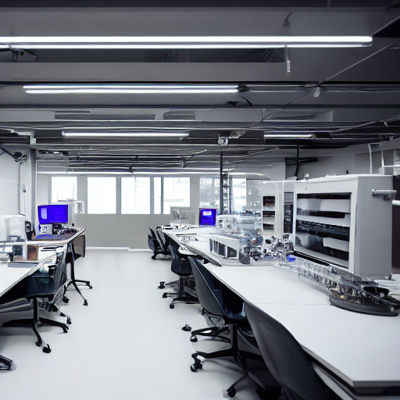

In [ ]:
from PIL import Image

# Load the saved image
img = Image.open("generated_image.png")

# Resize to max 400 px while keeping aspect ratio
img.thumbnail((400, 400))

# Display in Colab / Jupyter
display(img)


###**10. Vision Transformer (ViT) Base (Google)**
* Model ID: google/vit-base-patch16–224
* Downloads: 15M+
* Parameters: 86M

**What It Does:** Applies the transformer architecture (originally designed for text) to images. ViT treats images as sequences of patches, achieving state-of-the-art image classification.

**Best Use Cases:** Image classification, feature extraction for image search, transfer learning for custom vision tasks

**Why It’s Popular:** ViT proved that transformers aren’t just for text, they can match or exceed CNN performance on image tasks. This architectural unification has led to more efficient multimodal models. It’s become the foundation for modern computer vision systems.

In [ ]:
# Suppress non-critical warnings and logs
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

# Import Hugging Face pipelines, image handling, and HTTP request utilities
from transformers import pipeline
from PIL import Image
import requests

# Load a Vision Transformer (ViT) model for image classification
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

# URL of the image to classify
image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/beignets-task-guide.png"

# Download and open the image
image = Image.open(requests.get(image_url, stream=True).raw)

# Run image classification
results = classifier(image)

# Display the top 5 predicted labels with confidence scores
print("Top 5 predictions:")
for i, result in enumerate(results[:5], 1):
    print(f"{i}. {result['label']}: {result['score']:.2%}")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Top 5 predictions:
1. espresso: 18.18%
2. eggnog: 12.61%
3. coffee mug: 10.04%
4. cup: 8.16%
5. bakery, bakeshop, bakehouse: 6.09%


## **MY MODEL FROM HUGGINGFACE**
##**11. Facebook/wav2vec2-large-xlsr-53-spanish**

**Model ID:** `facebook/wav2vec2-large-xlsr-53-spanish`
**Downloads:** 5M+ (varies over time on Hugging Face)
**Parameters:** ~300M

**What It Does:**
Converts **spoken Spanish audio into text** using a self-supervised speech model. It is based on **Wav2Vec 2.0**, which learns speech representations directly from raw audio and is fine-tuned specifically for Spanish.

**Best Use Cases:**
* Spanish speech-to-text transcription
* Voice interfaces and assistants in Spanish
* Transcribing interviews, lectures, or podcasts
* Speech analysis and downstream NLP pipelines

**Why It’s Popular:**
It provides **high-quality Spanish ASR** without requiring Whisper, is **fully open source**, and works well on **free Colab GPUs**. The XLSR (cross-lingual speech representation) training allows strong performance even with limited labeled data, making it a go-to model for multilingual and Spanish speech recognition tasks.


**NOTE:** BY DEFECT this code takes .mp3 & .wav audio only.
> These libraries download audio, process it, and save it in the correct format.

* **`requests`**
  Downloads files or data from the web (e.g., fetch an audio file from a URL).

* **`librosa`**
  Loads and processes audio (resampling, converting to mono, extracting audio data).

* **`soundfile (sf)`**
  Saves audio data to files (e.g., write audio to a `.wav` file).



In [ ]:
import warnings
from transformers import pipeline, logging

# Suppress non-critical warnings and logs
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

# Load Spanish speech-to-text model
asr = pipeline(
    "automatic-speech-recognition",
    model="facebook/wav2vec2-large-xlsr-53-spanish",
    device=0  # use GPU if available
)

# RAW audio file URL from your GitHub repository
audio_url = "https://raw.githubusercontent.com/GigiQR99/NLP-exercise/main/SPFemale_BlancaM-[AudioTrimmer.com].mp3"

# Transcribe audio directly from GitHub
result = asr(audio_url)

# Print transcription
print(result["text"])


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/370 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

en este ejemplo seleccionamos el evento obtener signos vitales de la categoría valoración


In [ ]:
import warnings
import requests
import librosa
import soundfile as sf
from transformers import pipeline, logging

# Suppress non-critical warnings and logs
warnings.filterwarnings("ignore")
logging.set_verbosity_error()

# Load Spanish ASR model
asr = pipeline(
    "automatic-speech-recognition",
    model="facebook/wav2vec2-large-xlsr-53-spanish",
    device=0
)

# RAW GitHub audio URL (m4a)
audio_url = "https://raw.githubusercontent.com/GigiQR99/NLP-exercise/main/audio_espanol_seguro.m4a"

# Download audio locally
audio_path_m4a = "audio_espanol_seguro.m4a"
with open(audio_path_m4a, "wb") as f:
    f.write(requests.get(audio_url).content)

# Load and resample audio to 16 kHz (required by wav2vec2)
audio, sr = librosa.load(audio_path_m4a, sr=16000)

# Save as WAV
audio_path_wav = "audio_espanol_seguro.wav"
sf.write(audio_path_wav, audio, sr)

# Transcribe WAV audio
result = asr(audio_path_wav)

# Print transcription
print(result["text"])


este aviso contiene información sobre su cobertura de seguro


## **ResNet-50 image classification** 📷
#### **Image + confidence + Top-5 bar chart**

* **What it does:** Classifies an image into **one main label** with a confidence score (Top-1, Top-5).
* **Architecture:** 50-layer CNN with **residual (skip) connections**.
* **Parameters:** ~25.6M
* **Training:** ImageNet (1,000 classes, ~1.2M images)
* **Model size:** ~98 MB (pretrained)

**Why I used**

* Strong, reliable **baseline**
* Fast inference, light
* Pretrained → works out of the box
* Good accuracy vs compute trade-off

**What it’s good for**

* Single-subject images
* Quick demos, teaching, benchmarking
* Getting **“what is in this image?”**

**Limitations**

* ❌ **Only one label per image**
* ❌ No bounding boxes or localization
* ❌ Struggles with multiple objects or cluttered scenes

**Bottom line**
> ResNet-50 tells you **what the main object is**, not **where objects are** or **how many there are**.


Predicted object: Brabancon griffon


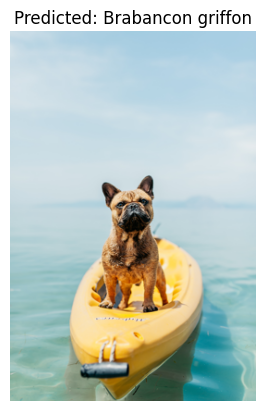

In [15]:
import warnings
warnings.filterwarnings("ignore")

from transformers import AutoImageProcessor, ResNetForImageClassification, logging
from PIL import Image
import requests
import torch
import matplotlib.pyplot as plt

logging.set_verbosity_error()

# Load image
image_url = "https://raw.githubusercontent.com/GigiQR99/CV-exercises/main/visuals/angelo-pantazis-wT3lf5qweEI-unsplash.jpg"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

# Load model
processor = AutoImageProcessor.from_pretrained("microsoft/resnet-50")
model = ResNetForImageClassification.from_pretrained("microsoft/resnet-50")
model.eval()

# Preprocess
inputs = processor(image, return_tensors="pt")

# Inference
with torch.no_grad():
    logits = model(**inputs).logits

# Decode prediction
predicted_class_id = logits.argmax(-1).item()
predicted_label = model.config.id2label[predicted_class_id]

print(f"Predicted object: {predicted_label}")

# Resize image (max 400px)
w, h = image.size
scale = 400 / max(w, h)
image_resized = image.resize((int(w * scale), int(h * scale)))

# Explicit render (THIS is the critical fix)
plt.imshow(image_resized)
plt.title(f"Predicted: {predicted_label}")
plt.axis("off")
plt.show()



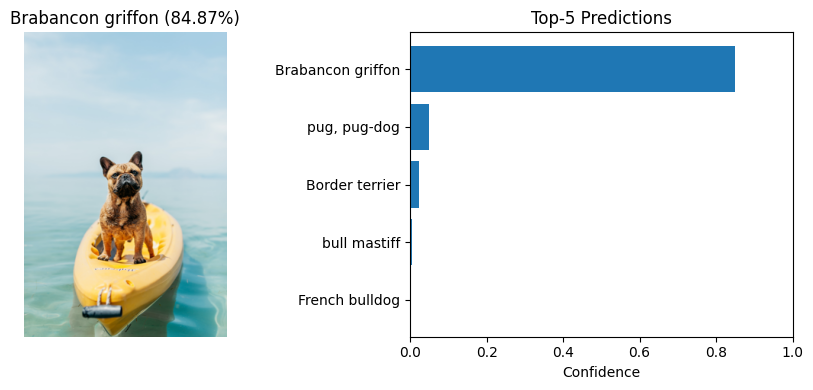

In [19]:
import warnings
warnings.filterwarnings("ignore")

from transformers import AutoImageProcessor, ResNetForImageClassification, logging
from PIL import Image
import requests
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

logging.set_verbosity_error()

# Load image
url = "https://raw.githubusercontent.com/GigiQR99/CV-exercises/main/visuals/angelo-pantazis-wT3lf5qweEI-unsplash.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Model
processor = AutoImageProcessor.from_pretrained("microsoft/resnet-50")
model = ResNetForImageClassification.from_pretrained("microsoft/resnet-50")
model.eval()

# Inference
inputs = processor(image, return_tensors="pt")
with torch.no_grad():
    logits = model(**inputs).logits

probs = F.softmax(logits, dim=-1)[0]

# Top-1
top1_id = probs.argmax().item()
top1_label = model.config.id2label[top1_id]
top1_conf = probs[top1_id].item()

# Top-5 (convert to lists — CRITICAL FIX)
top5_probs, top5_ids = torch.topk(probs, 5)
top5_probs = top5_probs.cpu().tolist()
top5_labels = [model.config.id2label[i.item()] for i in top5_ids]

# Resize image (≤400 px)
w, h = image.size
scale = 400 / max(w, h)
image_resized = image.resize((int(w * scale), int(h * scale)))

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Image panel
axes[0].imshow(image_resized)
axes[0].set_title(f"{top1_label} ({top1_conf:.2%})")
axes[0].axis("off")

# Bar chart panel (safe reversal)
axes[1].barh(top5_labels[::-1], top5_probs[::-1])
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Confidence")
axes[1].set_title("Top-5 Predictions")

plt.tight_layout()
plt.show()

